In [1]:
import pandas as pd

# Читаємо файл
df = pd.read_csv('Global YouTube Statistics.csv', encoding='latin-1')

# Дивимось на результат
df.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [2]:
# 3. Виведіть розміри датасету
print(f"Розмір датасету: {df.shape}")

# 4. Кількість пропусків у кожному стовпці
print("\nПропуски до обробки:")
print(df.isna().sum())

# 5. Заміна пропусків на середні значення (float)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Змінюємо тип на float
df[numeric_cols] = df[numeric_cols].astype(float)
print("\nОбробка пропущених значень завершена.")

Розмір датасету: (995, 28)

Пропуски до обробки:
rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                                 5
created_mon


Пропуски після обробки (у числових стовпцях):
rank                                       0
subscribers                                0
video views                                0
uploads                                    0
video_views_rank                           0
country_rank                               0
channel_type_rank                          0
video_views_for_the_last_30_days           0
lowest_monthly_earnings                    0
highest_monthly_earnings                   0
lowest_yearly_earnings                     0
highest_yearly_earnings                    0
subscribers_for_last_30_days               0
created_year                               0
created_date                               0
Gross tertiary education enrollment (%)    0
Population                                 0
Unemployment rate                          0
Urban_population                           0
Latitude                                   0
Longitude                                  0
dtype: i

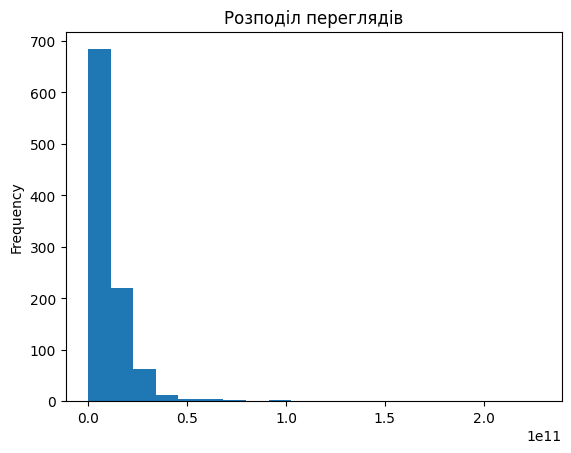

In [3]:
# 6. Ще раз перевірте кількість пропусків
print("\nПропуски після обробки (у числових стовпцях):")
print(df[numeric_cols].isna().sum())

# 7. Скільки унікальних країн
print(f"\nКількість унікальних країн: {df['Country'].nunique()}")

# 8. Діаграма розподілу переглядів
df['video views'].plot(kind='hist', bins=20, title='Розподіл переглядів')

# 9. Максимальна, мінімальна, середня кількість переглядів
print(f"\nМаксимум переглядів: {df['video views'].max()}")
print(f"Мінімум переглядів: {df['video views'].min()}")
print(f"Середнє переглядів: {df['video views'].mean()}")

In [4]:
# 10. Країна, де найбільше відео було завантажено
# Групуємо за країною та додаємо всі завантаження (uploads)
country_uploads = df.groupby('Country')['uploads'].sum()
print(f"Країна-лідер за завантаженнями: {country_uploads.idxmax()}")

# 11. Відео з найбільшою та найменшою кількістю завантажень (uploads)
video_max = df.loc[df['uploads'].idxmax(), 'Title']
video_min = df.loc[df['uploads'].idxmin(), 'Title']

print(f"Відео з найбільшою кількістю uploads: {video_max}")
print(f"Відео з найменшою кількістю uploads: {video_min}")

Країна-лідер за завантаженнями: India
Відео з найбільшою кількістю uploads: ABP NEWS
Відео з найменшою кількістю uploads: Music


In [5]:
# 1. Прочитайте csv файл
df_books = pd.read_csv('bestsellers with categories.csv')

# Виведіть перші 10 рядків
print("Перші 10 рядків книг:")
print(df_books.head(10))

# Виведіть розміри датасету
print(f"\nРозмір датасету книг: {df_books.shape}")

# Про скільки книг зберігає дані датасет?
# Оскільки книги можуть повторюватися, рахуємо унікальні назви
unique_books = df_books['Name'].nunique()
print(f"Датасет містить дані про {unique_books} унікальних книг.")

Перші 10 рядків книг:
                                                Name  \
0                      10-Day Green Smoothie Cleanse   
1                                  11/22/63: A Novel   
2            12 Rules for Life: An Antidote to Chaos   
3                             1984 (Signet Classics)   
4  5,000 Awesome Facts (About Everything!) (Natio...   
5      A Dance with Dragons (A Song of Ice and Fire)   
6  A Game of Thrones / A Clash of Kings / A Storm...   
7                     A Gentleman in Moscow: A Novel   
8      A Higher Loyalty: Truth, Lies, and Leadership   
9                          A Man Called Ove: A Novel   

                     Author  User Rating  Reviews  Price  Year        Genre  
0                  JJ Smith          4.7    17350      8  2016  Non Fiction  
1              Stephen King          4.6     2052     22  2011      Fiction  
2        Jordan B. Peterson          4.7    18979     15  2018  Non Fiction  
3             George Orwell          4.7    21424